# PDAS CA2
# What job industries offer the highest salary and best stability?
This study examines which job industries in Singapore provide the most attractive combination of high salary and strong employment stability. As individual job preferences are not directly observable in employment datasets, gross monthly income is used as a proxy for salary attractiveness, while employment stability is represented by indicators such as overall employment rate and full-time permanent employment rate.

By analysing trends across major industry groups `Construction, Manufacturing, Services, and Others` and over multiple years, this study aims to identify industries that offer favourable trade-offs between income levels and job security. The findings are intended to support individuals in making more informed career decisions by highlighting industries that balance financial rewards with long-term employment stability.



In [63]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

# Load CSV files ```````````````````````````````````````````````````````````````````````````
ge1 = pd.read_csv("(1) graduate employment survey modified.csv") 
ge2 = pd.read_csv("(2) graduate employment survey modified .csv") 
print("ge1")
ge1.info()
print("ge2")
ge2.info()


ge1
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5135 entries, 0 to 5134
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   year        5135 non-null   object
 1   university  5135 non-null   object
 2   school      5135 non-null   object
 3   degree      5135 non-null   object
 4   Key         5135 non-null   int64 
dtypes: int64(1), object(4)
memory usage: 200.7+ KB
ge2
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5135 entries, 0 to 5134
Data columns (total 48 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   employment_rate_overall      5027 non-null   object 
 1   employment_rate_ft_perm      5027 non-null   object 
 2   basic_monthly_mean           5027 non-null   object 
 3   basic_monthly_median         5027 non-null   object 
 4   gross_monthly_mean           5027 non-null   object 
 5   gross_monthly_median         5027 no

In [64]:
ge1.head()

,year,university,school,degree,Key
0,2013,Nanyang Technological University,College of Business (Nanyang Business School),Accountancy and Business,1
1,2013,Nanyang Technological University,College of Business (Nanyang Business School),Accountancy (3-yr direct Honours Programme),2
2,2013,Nanyang Technological University,College of Business (Nanyang Business School),Business (3-yr direct Honours Programme),3
3,2013,Nanyang Technological University,College of Business (Nanyang Business School),Business and Computing,4
4,2013,Nanyang Technological University,College of Engineering,Aerospace Engineering,5


In [65]:
ge2.head()

,employment_rate_overall,employment_rate_ft_perm,basic_monthly_mean,basic_monthly_median,gross_monthly_mean,gross_monthly_median,gross_mthly_25_percentile,gross_mthly_75_percentile,gross_monthly_mean.1,gross_monthly_median.1,...,Unnamed: 38,Unnamed: 39,Unnamed: 40,Unnamed: 41,Unnamed: 42,Unnamed: 43,Unnamed: 44,Unnamed: 45,Unnamed: 46,Key
0,97.4,96.1,3701,3200,3727,3350,2900,4000,3727,3350,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1,97.1,95.7,2850,2700,2938,2700,2700,2900,2938,2700,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
2,90.9,85.7,3053,3000,3214,3000,2700,3500,3214,3000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
3,87.5,87.5,3557,3400,3615,3400,3000,4100,3615,3400,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4
4,95.3,95.3,3494,3500,3536,3500,3100,3816,3536,3500,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5


In [66]:
# Merge datasets 
df = pd.merge(ge1, ge2, on = "Key", how="inner")
df = df.loc[:, ~df.columns.str.contains("Unnamed", case=False)]

# Save cleaned dataset
df.to_csv("ge_merged.csv", index=False)

In [67]:
final_df = df.copy()
final_df.info()
final_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5135 entries, 0 to 5134
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   year                         5135 non-null   object
 1   university                   5135 non-null   object
 2   school                       5135 non-null   object
 3   degree                       5135 non-null   object
 4   Key                          5135 non-null   int64 
 5   employment_rate_overall      5027 non-null   object
 6   employment_rate_ft_perm      5027 non-null   object
 7   basic_monthly_mean           5027 non-null   object
 8   basic_monthly_median         5027 non-null   object
 9   gross_monthly_mean           5027 non-null   object
 10  gross_monthly_median         5027 non-null   object
 11  gross_mthly_25_percentile    5027 non-null   object
 12  gross_mthly_75_percentile    5027 non-null   object
 13  gross_monthly_mean.1         5027

,year,university,school,degree,Key,employment_rate_overall,employment_rate_ft_perm,basic_monthly_mean,basic_monthly_median,gross_monthly_mean,gross_monthly_median,gross_mthly_25_percentile,gross_mthly_75_percentile,gross_monthly_mean.1,gross_monthly_median.1,gross_mthly_25_percentile.1,gross_mthly_75_percentile.1
0,2013,Nanyang Technological University,College of Business (Nanyang Business School),Accountancy and Business,1,97.4,96.1,3701,3200,3727,3350,2900,4000,3727,3350,2900,4000
1,2013,Nanyang Technological University,College of Business (Nanyang Business School),Accountancy (3-yr direct Honours Programme),2,97.1,95.7,2850,2700,2938,2700,2700,2900,2938,2700,2700,2900
2,2013,Nanyang Technological University,College of Business (Nanyang Business School),Business (3-yr direct Honours Programme),3,90.9,85.7,3053,3000,3214,3000,2700,3500,3214,3000,2700,3500
3,2013,Nanyang Technological University,College of Business (Nanyang Business School),Business and Computing,4,87.5,87.5,3557,3400,3615,3400,3000,4100,3615,3400,3000,4100
4,2013,Nanyang Technological University,College of Engineering,Aerospace Engineering,5,95.3,95.3,3494,3500,3536,3500,3100,3816,3536,3500,3100,3816


In [68]:
# Cleaning Graduate Employment
# Check for duplicates
duplicate_count = final_df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

# Remove duplicates if any
if duplicate_count > 0:
    final_df = final_df.drop_duplicates()
    print("Duplicates removed. New shape:", final_df.shape)
else:
    print("No duplicate rows found.")

# Check for duplicated columns (by values)
duplicate_col_count = final_df.T.duplicated().sum()
print("Number of duplicate columns:", duplicate_col_count)

# Remove duplicated columns 
final_df = final_df.loc[:, ~final_df.T.duplicated()]

print("New shape after dropping duplicate columns:", final_df.info())  

Number of duplicate rows: 0
No duplicate rows found.
Number of duplicate columns: 4
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5135 entries, 0 to 5134
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   year                       5135 non-null   object
 1   university                 5135 non-null   object
 2   school                     5135 non-null   object
 3   degree                     5135 non-null   object
 4   Key                        5135 non-null   int64 
 5   employment_rate_overall    5027 non-null   object
 6   employment_rate_ft_perm    5027 non-null   object
 7   basic_monthly_mean         5027 non-null   object
 8   basic_monthly_median       5027 non-null   object
 9   gross_monthly_mean         5027 non-null   object
 10  gross_monthly_median       5027 non-null   object
 11  gross_mthly_25_percentile  5027 non-null   object
 12  gross_mthly_75_percentile  5027 no

In [69]:
# Check for missing values
print("--- Empty values ---")
print(final_df.isna().sum())

# Drop completely empty rows
final_df = final_df.dropna()

print("--- After Dropping ---")
print(final_df.isna().sum())

--- Empty values ---
year                           0
university                     0
school                         0
degree                         0
Key                            0
employment_rate_overall      108
employment_rate_ft_perm      108
basic_monthly_mean           108
basic_monthly_median         108
gross_monthly_mean           108
gross_monthly_median         108
gross_mthly_25_percentile    108
gross_mthly_75_percentile    108
dtype: int64
--- After Dropping ---
year                         0
university                   0
school                       0
degree                       0
Key                          0
employment_rate_overall      0
employment_rate_ft_perm      0
basic_monthly_mean           0
basic_monthly_median         0
gross_monthly_mean           0
gross_monthly_median         0
gross_mthly_25_percentile    0
gross_mthly_75_percentile    0
dtype: int64


### 1. Distribution of salary
Observe if the salaries are bell-shaped and leaning towards the right or left as well as the most common salaries by count

In [70]:
income_df = pd.read_csv("FT_Res_ind_income.csv")
income_df.info()
print(income_df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 384 entries, 0 to 383
Data columns (total 4 columns):
 #   Column                                              Non-Null Count  Dtype 
---  ------                                              --------------  ----- 
 0   year                                                384 non-null    object
 1   industry                                            384 non-null    object
 2   median_gross_monthly_income_including_employer_cpf  384 non-null    int64 
 3   median_gross_monthly_income_excluding_employer_cpf  384 non-null    int64 
dtypes: int64(2), object(2)
memory usage: 12.1+ KB
year                                                  0
industry                                              0
median_gross_monthly_income_including_employer_cpf    0
median_gross_monthly_income_excluding_employer_cpf    0
dtype: int64


In [71]:
# 1. Convert the 'year' column to numeric
# 'errors=coerce' will turn any non-numeric text into NaN (null)
income_df['year_numeric'] = pd.to_numeric(income_df['year'], errors='coerce')

# 2. Filter the DataFrame for the years 2020 to 2024
# Using .copy() ensures the new df is an independent object
income24df = income_df[(income_df['year_numeric'] >= 2012) & (income_df['year_numeric'] <= 2022)].copy()

# 3. Remove the helper numeric column and reset the index
income24df = income24df.drop(columns=['year_numeric']).reset_index(drop=True)

# Verify the result
print(income24df['year'].unique())
print(income24df.head())
print(income24df.info())
print(income24df['industry'].head())

['2012' '2013' '2014' '2015' '2016' '2017' '2018' '2019' '2020' '2021'
 '2022']
   year                  industry  \
0  2012             manufacturing   
1  2012              construction   
2  2012                  services   
3  2012  wholesale & retail trade   
4  2012  transportation & storage   

   median_gross_monthly_income_including_employer_cpf  \
0                                               3770    
1                                               3263    
2                                               3384    
3                                               3000    
4                                               2500    

   median_gross_monthly_income_excluding_employer_cpf  
0                                               3300   
1                                               3000   
2                                               3000   
3                                               2708   
4                                               2167   
<class 'pandas.cor

In [72]:
# 1. Define the list of industries you want to keep
target_industries = ["manufacturing", "construction", "services", "others"]

# 2. Filter the dataframe to only include rows where 'industry' matches one of those 4
# We use .copy() to make it a standalone dataframe for your analysis
income24df = income24df[income24df['industry'].isin(target_industries)].copy()

# 3. If you want to put these into a brand new column (leaving the old one as is)
income24df['new_industry'] = income24df['industry']

# Verify the result
print(income24df['new_industry'].unique())
print(f"Number of rows kept: {len(income24df)}")
# View the first 5 full rows
print(income24df.info())

['manufacturing' 'construction' 'services' 'others']
Number of rows kept: 44
<class 'pandas.core.frame.DataFrame'>
Index: 44 entries, 0 to 175
Data columns (total 5 columns):
 #   Column                                              Non-Null Count  Dtype 
---  ------                                              --------------  ----- 
 0   year                                                44 non-null     object
 1   industry                                            44 non-null     object
 2   median_gross_monthly_income_including_employer_cpf  44 non-null     int64 
 3   median_gross_monthly_income_excluding_employer_cpf  44 non-null     int64 
 4   new_industry                                        44 non-null     object
dtypes: int64(2), object(3)
memory usage: 2.1+ KB
None


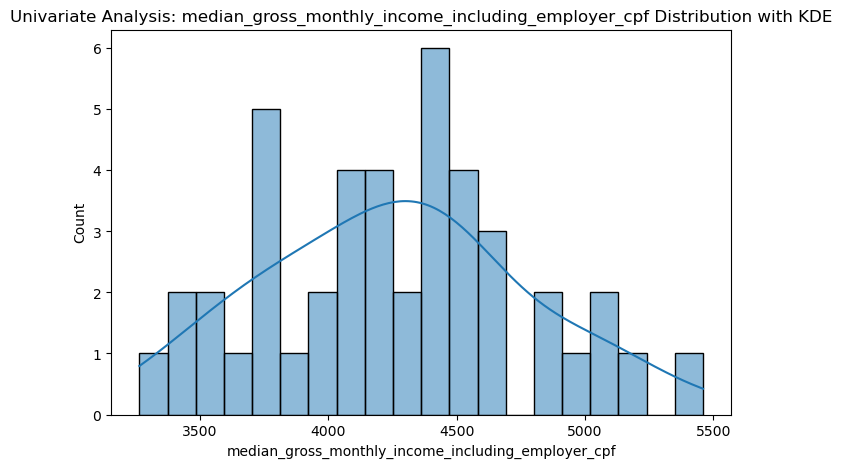

In [73]:
plt.figure(figsize=(8, 5))
sns.histplot(income24df["median_gross_monthly_income_including_employer_cpf"], kde=True, bins=20)
plt.title("Univariate Analysis: median_gross_monthly_income_including_employer_cpf Distribution with KDE")
plt.show()

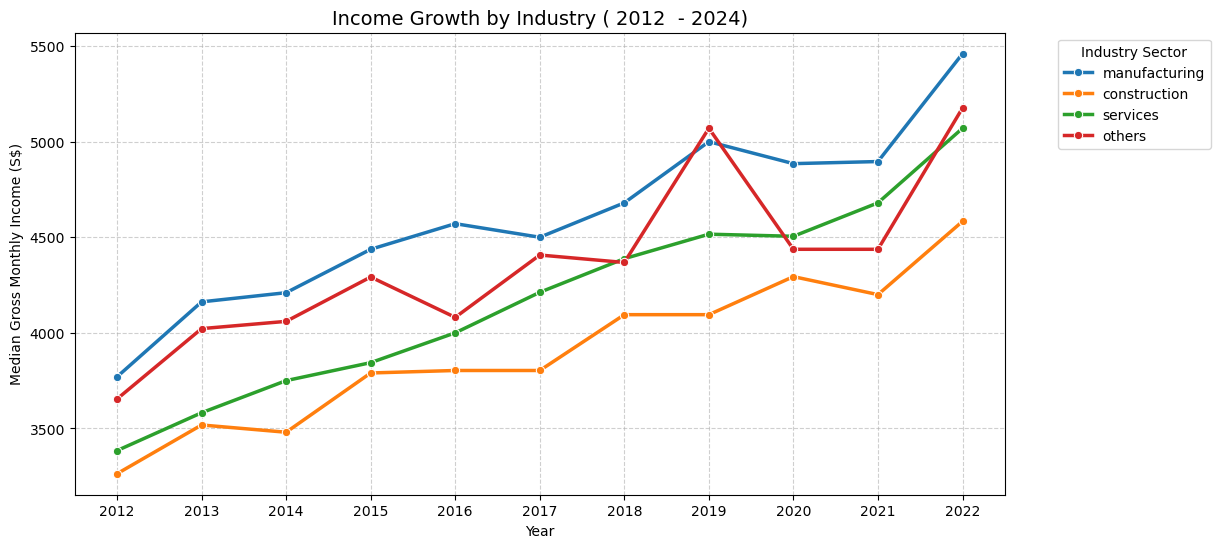

In [74]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=income24df, x='year', y='median_gross_monthly_income_including_employer_cpf', 
             hue='industry', marker='o', linewidth=2.5)

plt.title('Income Growth by Industry ( 2012  - 2024)', fontsize=14)
plt.ylabel('Median Gross Monthly Income (S$)')
plt.xlabel('Year')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Industry Sector', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

### 2. Stability Differences between Job Industries
This analysis compares employment stability across major job industries in Singapore to identify sectors with more consistent employment outcomes over time.

In [75]:
employment_df = pd.read_csv("mrsd_4_annl_emp_chg_by_ind_28042025.csv")
employment_df.info()
print(employment_df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1008 entries, 0 to 1007
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   year               1008 non-null   int64 
 1   industry1          1008 non-null   object
 2   industry2          1008 non-null   object
 3   industry3          1008 non-null   object
 4   employment_change  1008 non-null   object
dtypes: int64(1), object(4)
memory usage: 39.5+ KB
year                 0
industry1            0
industry2            0
industry3            0
employment_change    0
dtype: int64


In [76]:
# 1. Convert the 'year' column to numeric
# 'errors=coerce' will turn any non-numeric text into NaN (null)
employment_df['year_numeric'] = pd.to_numeric(employment_df['year'], errors='coerce')

# 2. Filter the DataFrame for the years 2020 to 2024
# Using .copy() ensures the new df is an independent object
employment24df = employment_df[(employment_df['year_numeric'] >= 2012) & (employment_df['year_numeric'] <= 2022)].copy()

# 3. Remove the helper numeric column and reset the index
employment24df = employment24df.drop(columns=['year_numeric']).reset_index(drop=True)

# Verify the result
print(employment24df['year'].unique())
print(employment24df.head())
print(employment24df.info())
print(employment24df['industry1'].head())



[2012 2013 2014 2015 2016 2017 2018 2019 2020 2021 2022]
   year      industry1                                        industry2  \
0  2012         others                                           others   
1  2012   construction                                     construction   
2  2012  manufacturing                      food, beverages and tobacco   
3  2012  manufacturing   paper / rubber / plastic products and printing   
4  2012  manufacturing  petroleum, chemical and pharmaceutical products   

                                         industry3 employment_change  
0                                           others               1.6  
1                                     construction              40.4  
2                      food, beverages and tobacco               1.6  
3   paper / rubber / plastic products and printing                -2  
4  petroleum, chemical and pharmaceutical products              11.9  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 363 entries, 0 t

In [77]:
# 1. Define the list of industries you want to keep
target_industries = ["manufacturing", "construction", "services", "others"]

# 2. Filter the dataframe to only include rows where 'industry1' matches one of those 4
# We use .copy() to make it a standalone dataframe for your analysis
employment24df = employment24df[employment24df["industry1"].isin(target_industries)].copy()

# Optional: create a clean industry column like Format 1
employment24df["industry"] = employment24df["industry1"]

# --- 2) Ensure year + employment_change are numeric ---
employment24df["year"] = pd.to_numeric(employment24df["year"], errors="coerce")
employment24df["employment_change"] = pd.to_numeric(employment24df["employment_change"], errors="coerce")

# --- 3) Drop invalid rows (from * / blanks / non-numeric) ---
employment24df = employment24df.dropna(subset=["year", "industry", "employment_change"])

# --- 4) Aggregate to 1 row per year + industry (Format 2 output) ---
year_industry_change = (
    employment24df
    .groupby(["year", "industry"], as_index=False)["employment_change"]
    .mean()
    .sort_values(["year", "industry"])
    .reset_index(drop=True)
)

# --- 5) Verify result ---
print(year_industry_change["industry"].unique())
print(year_industry_change.head())
print(year_industry_change.info())
print("Rows:", len(year_industry_change))
print(year_industry_change.groupby("year")["industry"].nunique().head())


['construction' 'manufacturing' 'others' 'services']
   year       industry  employment_change
0  2012   construction          40.400000
1  2012  manufacturing           1.285714
2  2012         others           1.600000
3  2012       services           3.245833
4  2013   construction          38.600000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44 entries, 0 to 43
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   year               44 non-null     int64  
 1   industry           44 non-null     object 
 2   employment_change  44 non-null     float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.2+ KB
None
Rows: 44
year
2012    4
2013    4
2014    4
2015    4
2016    4
Name: industry, dtype: int64


industry  construction  manufacturing  others  services
year                                                   
2012              40.4       1.285714     1.6  3.245833
2013              38.6       0.642857     1.7  3.795833
2014              14.7      -0.571429     0.8  4.941667
2015               6.4      -3.400000     0.2  1.929167
2016             -11.8      -2.142857    -0.2  1.837500
industry
others            0.755104
services          2.468495
manufacturing     2.615026
construction     39.131543
Name: employment_change, dtype: float64


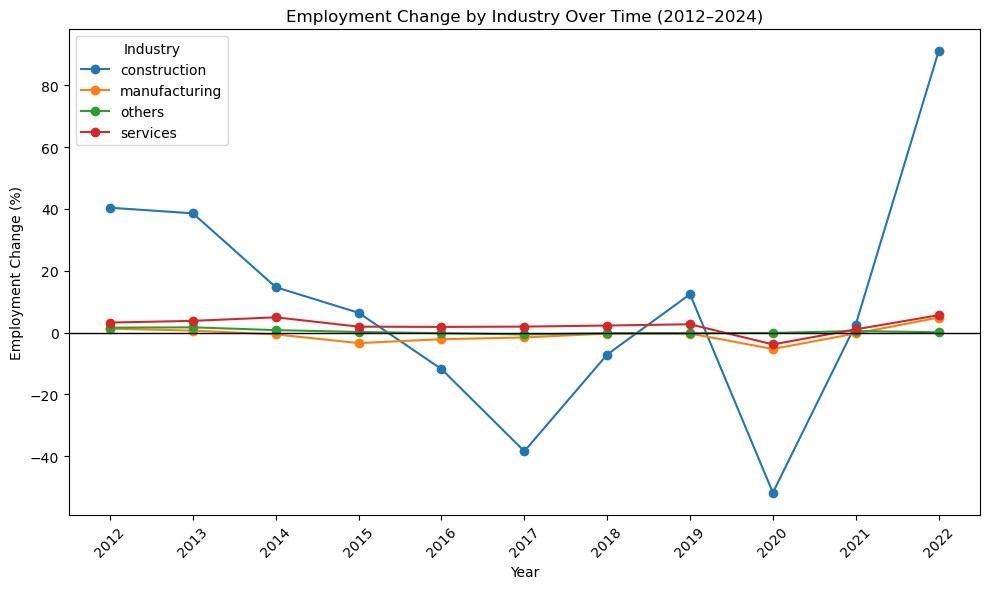

In [78]:
year_industry_change_wide = (
    year_industry_change
    .pivot(index="year", columns="industry", values="employment_change")
    .sort_index()
)

print(year_industry_change_wide.head())
stability_score = (
    year_industry_change
    .groupby("industry")["employment_change"]
    .std()
    .sort_values()
)

print(stability_score)

plt.figure(figsize=(10,6))

for ind in year_industry_change_wide.columns:
    plt.plot(
        year_industry_change_wide.index,
        year_industry_change_wide[ind],
        label=ind,
        marker="o"
    )

plt.axhline(0, color="black", linewidth=1)
plt.xlabel("Year")
plt.ylabel("Employment Change (%)")
plt.title("Employment Change by Industry Over Time (2012–2024)")
plt.legend(title="Industry")
plt.xticks(year_industry_change_wide.index, rotation=45)
plt.tight_layout()
plt.show()



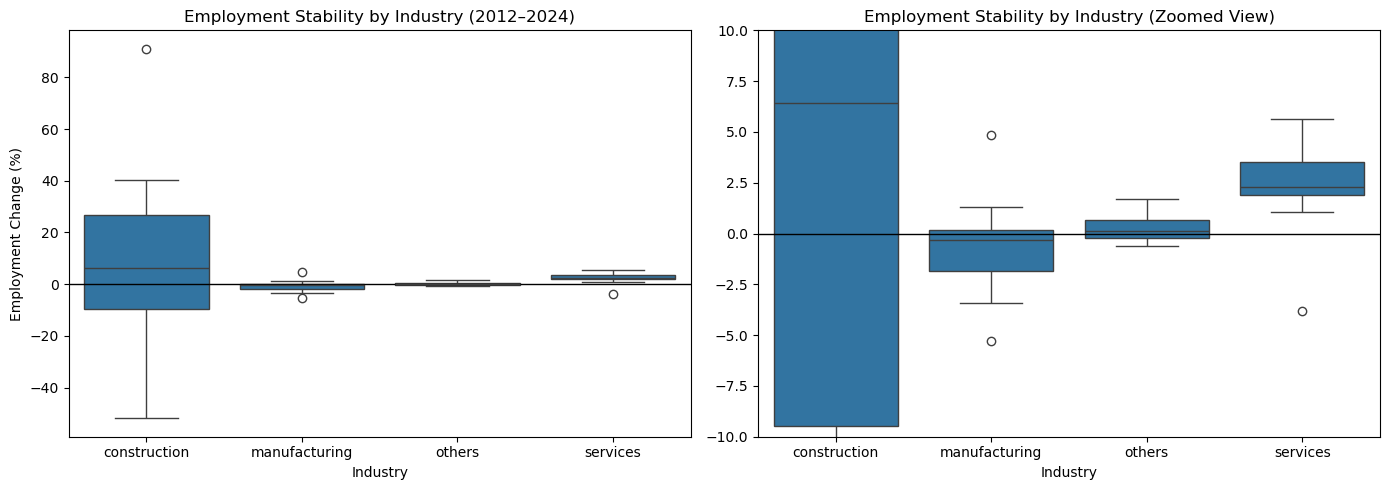

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

# --- LEFT: Full range (overall volatility) ---
sns.boxplot(
    data=year_industry_change,
    x="industry",
    y="employment_change",
    ax=axes[0]
)

axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Employment Stability by Industry (2012–2024)")
axes[0].set_xlabel("Industry")
axes[0].set_ylabel("Employment Change (%)")

# --- RIGHT: Zoomed-in view ---
sns.boxplot(
    data=year_industry_change,
    x="industry",
    y="employment_change",
    ax=axes[1]
)

axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_ylim(-10, 10)
axes[1].set_title("Employment Stability by Industry (Zoomed View)")
axes[1].set_xlabel("Industry")
axes[1].set_ylabel("")  # cleaner look

plt.tight_layout()
plt.show()


### 3. Differences between Salary and Employment Rates
This analysis compares employment stability across major job industries in Singapore to identify sectors with more consistent employment outcomes over time.

Correlation (salary median vs overall employment): 0.353


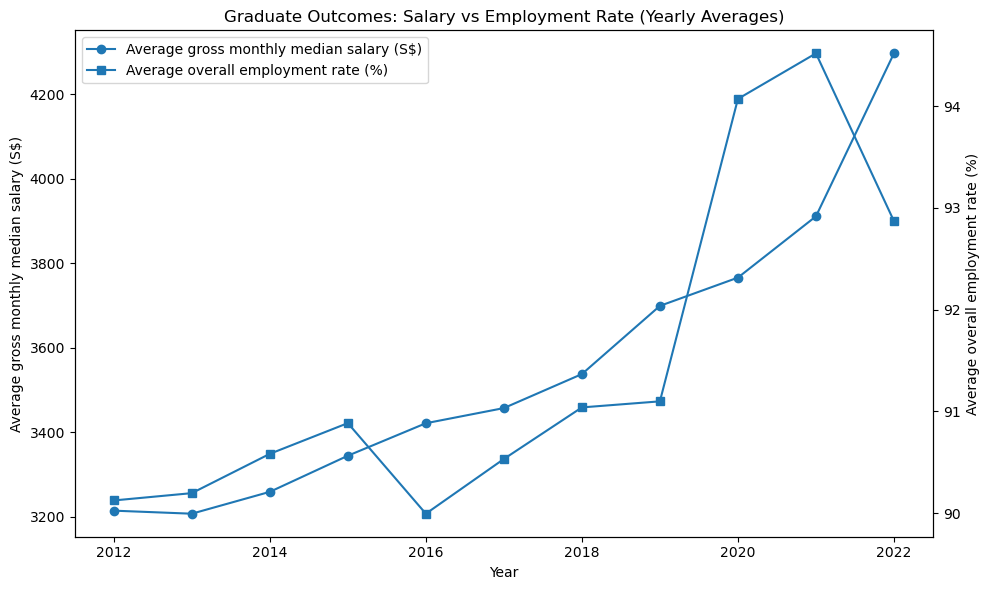

In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("ge_merged.csv")

# 1) Drop duplicate salary columns (the ones ending with ".1")
df = df.drop(columns=[c for c in df.columns if c.endswith(".1")])

# 2) Convert numeric columns
num_cols = [
    "employment_rate_overall",
    "employment_rate_ft_perm",
    "basic_monthly_mean",
    "basic_monthly_median",
    "gross_monthly_mean",
    "gross_monthly_median",
    "gross_mthly_25_percentile",
    "gross_mthly_75_percentile",
]
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")

# 3) Fix 2012 salary scale issue (in this file, 2012 salaries are 10x smaller)
salary_cols = [
    "basic_monthly_mean",
    "basic_monthly_median",
    "gross_monthly_mean",
    "gross_monthly_median",
    "gross_mthly_25_percentile",
    "gross_mthly_75_percentile",
]
mask_2012 = (df["year"] == 2012)
mask_small = df["gross_monthly_median"] < 1000
df.loc[mask_2012 & mask_small, salary_cols] = df.loc[mask_2012 & mask_small, salary_cols] * 10

# 4) Keep rows with key metrics
df_clean = df.dropna(subset=["year", "employment_rate_overall", "gross_monthly_median"]).copy()

# 5) Yearly averages
yearly = (
    df_clean.groupby("year", as_index=False)
    .agg(
        avg_employment_overall=("employment_rate_overall", "mean"),
        avg_employment_ft_perm=("employment_rate_ft_perm", "mean"),
        avg_gross_median=("gross_monthly_median", "mean"),
        n_programmes=("Key", "count"),
    )
    .sort_values("year")
)

overall_corr = df_clean["gross_monthly_median"].corr(df_clean["employment_rate_overall"])
print("Correlation (salary median vs overall employment):", round(overall_corr, 3))

# -------------------------
# GRAPH 1: Salary vs employment over time (dual axis) + LEGEND
# -------------------------
fig, ax1 = plt.subplots(figsize=(10, 6))

# Salary line (left axis)
line1, = ax1.plot(
    yearly["year"],
    yearly["avg_gross_median"],
    marker="o",
    label="Average gross monthly median salary (S$)"
)
ax1.set_xlabel("Year")
ax1.set_ylabel("Average gross monthly median salary (S$)")

# Employment line (right axis)
ax2 = ax1.twinx()
line2, = ax2.plot(
    yearly["year"],
    yearly["avg_employment_overall"],
    marker="s",
    label="Average overall employment rate (%)"
)
ax2.set_ylabel("Average overall employment rate (%)")

# ✅ Combine legends from both axes
ax1.legend(handles=[line1, line2], loc="upper left")

plt.title("Graduate Outcomes: Salary vs Employment Rate (Yearly Averages)")
plt.tight_layout()
plt.show()

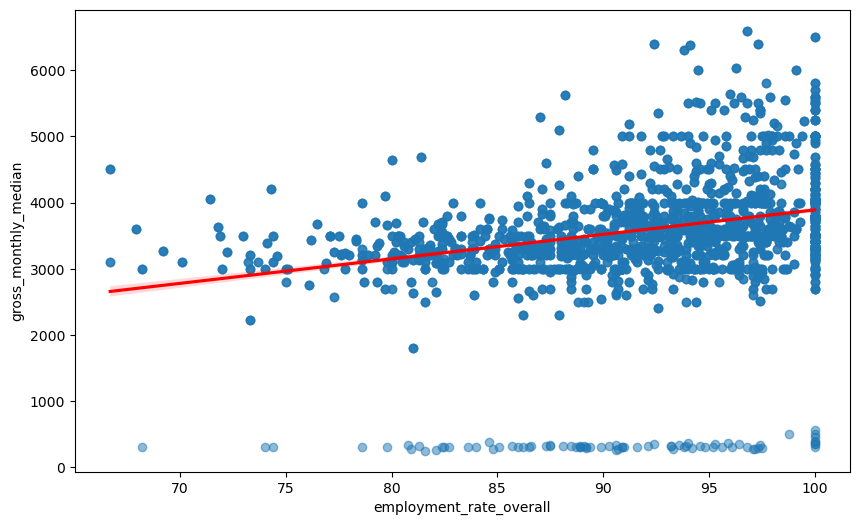

In [82]:
# 1. Force the columns to be numeric (this is likely what was missing in final_df)
cols_to_fix = ["employment_rate_overall", "gross_monthly_median", "year"]

for col in cols_to_fix:
    # errors='coerce' turns non-numeric junk into NaN
    final_df[col] = pd.to_numeric(final_df[col], errors='coerce')

# 2. Now drop the NaNs created by the conversion (if any)
df_clean = final_df.dropna(subset=cols_to_fix).copy()

# 3. Filter for your years
df_filtered = df_clean[(df_clean['year'] >= 2012) & (df_clean['year'] <= 2022)]

# 4. Plot again - it should now be a clean numerical scale
plt.figure(figsize=(10, 6))
sns.regplot(
    data=df_filtered, 
    x="employment_rate_overall", 
    y="gross_monthly_median",
    scatter_kws={'alpha':0.5},
    line_kws={'color':'red'}
)
plt.show()

In [83]:
import numpy as np

# 1. First, ensure your columns are numeric (fixing the DType error from before)
cols_to_fix = ["year", "employment_rate_overall", "gross_monthly_median"]
for col in cols_to_fix:
    final_df[col] = pd.to_numeric(final_df[col], errors='coerce')

# 2. Define the keyword conditions
# We search the 'degree' column for specific industry-related words
conditions = [
    final_df['degree'].str.contains('Mechanical|Manufacturing|Industrial|Materials', case=False, na=False),
    final_df['degree'].str.contains('Civil|Real Estate|Building|Construction', case=False, na=False),
    final_df['degree'].str.contains('Business|Accountancy|Banking|Finance|Hospitality|Nursing|Social', case=False, na=False)
]

# 3. Define the labels
choices = ['manufacturing', 'construction', 'services']

# 4. Create the new column (default everything else to 'others')
final_df['inferred_industry'] = np.select(conditions, choices, default='others')

In [84]:
# 1. Check Data Types and Non-Null Counts
print("--- DATAFRAME INFO ---")
print(final_df.info())

# 2. Check Dimensions
print("\n--- DATAFRAME SHAPE ---")
print(f"Rows: {final_df.shape[0]}, Columns: {final_df.shape[1]}")

# 3. Preview the first few rows (specifically looking at the new industry mapping)
print("\n--- DATA PREVIEW ---")
# Selecting specific columns to make the preview readable
cols_to_view = ['year', 'degree', 'inferred_industry', 'gross_monthly_median']
print(final_df[cols_to_view].head(10))

--- DATAFRAME INFO ---
<class 'pandas.core.frame.DataFrame'>
Index: 5027 entries, 0 to 5134
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   year                       5026 non-null   float64
 1   university                 5027 non-null   object 
 2   school                     5027 non-null   object 
 3   degree                     5027 non-null   object 
 4   Key                        5027 non-null   int64  
 5   employment_rate_overall    4656 non-null   float64
 6   employment_rate_ft_perm    5027 non-null   object 
 7   basic_monthly_mean         5027 non-null   object 
 8   basic_monthly_median       5027 non-null   object 
 9   gross_monthly_mean         5027 non-null   object 
 10  gross_monthly_median       4656 non-null   float64
 11  gross_mthly_25_percentile  5027 non-null   object 
 12  gross_mthly_75_percentile  5027 non-null   object 
 13  inferred_industry          502

In [89]:
# 1. Ensure the 'year' column is numeric (if not already done)
# This allows us to use mathematical operators like >= and <=
final_df['year'] = pd.to_numeric(final_df['year'], errors='coerce')

# 2. Filter for the years 2012 to 2022
# We create a new dataframe called 'df_filtered' so we don't lose the original data
df_filtered = final_df[(final_df['year'] >= 2012) & (final_df['year'] <= 2022)].copy()

# 3. Check the total number of rows after filtering
print(f"Total rows between 2012 and 2022: {df_filtered.shape[0]}")

# 4. Count the rows in each industry
# This tells you how well your keyword search performed
industry_counts = df_filtered['inferred_industry'].value_counts()

print("\n--- Rows per Industry (2012-2022) ---")
print(industry_counts)

# 5. Visualizing the structure of the filtered data
print("\n--- Filtered Data Info ---")
df_filtered.info()

Total rows between 2012 and 2022: 5026

--- Rows per Industry (2012-2022) ---
inferred_industry
others           3626
services          894
manufacturing     350
construction      156
Name: count, dtype: int64

--- Filtered Data Info ---
<class 'pandas.core.frame.DataFrame'>
Index: 5026 entries, 0 to 5134
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   year                       5026 non-null   float64
 1   university                 5026 non-null   object 
 2   school                     5026 non-null   object 
 3   degree                     5026 non-null   object 
 4   Key                        5026 non-null   int64  
 5   employment_rate_overall    4656 non-null   float64
 6   employment_rate_ft_perm    5026 non-null   object 
 7   basic_monthly_mean         5026 non-null   object 
 8   basic_monthly_median       5026 non-null   object 
 9   gross_monthly_mean         5026 non-nul

In [90]:
# Group the 5,026 rows into just 44 rows (4 industries * 11 years)
grad_summary = df_filtered.groupby(['year', 'inferred_industry']).agg({
    'gross_monthly_median': 'mean', # Average salary of all degrees in that industry
    'employment_rate_overall': 'mean'
}).reset_index()

print(grad_summary.shape) 
# This should now be around 44 rows—perfectly matching your other dataset's scale!

(44, 4)


Columns in grad_summary: ['year', 'inferred_industry', 'avg_employment_overall', 'avg_gross_median']


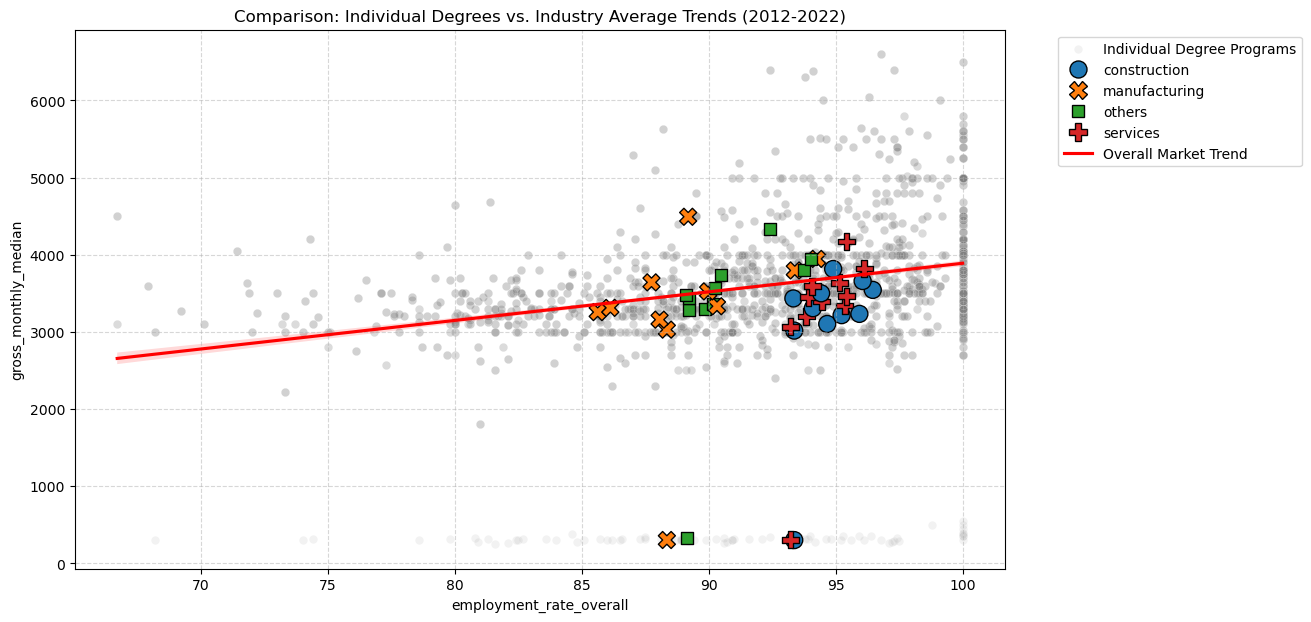

In [92]:
# 1. Re-create the summary to ensure the column names are exactly what we expect
grad_summary = df_filtered.groupby(['year', 'inferred_industry']).agg(
    avg_employment_overall=('employment_rate_overall', 'mean'),
    avg_gross_median=('gross_monthly_median', 'mean')
).reset_index()

# Verify names (this should show: ['year', 'inferred_industry', 'avg_employment_overall', 'avg_gross_median'])
print("Columns in grad_summary:", grad_summary.columns.tolist())

plt.figure(figsize=(12, 7))

# 2. Plot the raw data (df_filtered)
sns.scatterplot(
    data=df_filtered, 
    x="employment_rate_overall", 
    y="gross_monthly_median",
    alpha=0.1,
    color='gray',
    label="Individual Degree Programs"
)

# 3. Plot the aggregated summary (grad_summary)
# Notice 'x' and 'y' now match the names we defined in step 1
sns.scatterplot(
    data=grad_summary, 
    x="avg_employment_overall", # Updated from employment_rate_overall
    y="avg_gross_median", 
    hue="inferred_industry", 
    style="inferred_industry",
    s=150, 
    edgecolor='black'
)

# 4. Add the trend line using the raw data
sns.regplot(
    data=df_filtered, 
    x="employment_rate_overall", 
    y="gross_monthly_median",
    scatter=False, 
    color='red', 
    label="Overall Market Trend"
)

plt.title("Comparison: Individual Degrees vs. Industry Average Trends (2012-2022)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Step 1: Inferred Industry (Keyword Search & Mapping)
- **What we did**
  - Used `np.select()` to search the `degree` column for keywords such as "Civil", "Mechanical", and "Business"
  - Mapped degrees into four categories: Manufacturing, Construction, Services, and Others

- **What it does**
  - Categorizes 5,000+ messy individual degree names into four clean industry buckets

- **Why we did it**
  - The original dataset was too granular for analysis
  - Inferring industries allows direct comparison with national employment trends
  - Demonstrates Data Transformation skills

--- 
# Step 2: Data Type Correction (Numeric Conversion)
- **What we did**
  - Used `pd.to_numeric()` with `errors='coerce'` on columns such as `year` and `gross_monthly_median`

- **What it does**
  - Converts text-based (object) columns into numeric data types (int/float)

- **Why we did it**
  - Mathematical operations and regression lines cannot be performed on text data
  - Fixes `DTypePromotionError`
  - Ensures graph axes use a numerical scale

--- 
# Step 3: Data Filtering (2012–2022)
- **What we did**
  - Created a boolean mask:
    - `(df['year'] >= 2012) & (df['year'] <= 2022)`

- **What it does**
  - Removes data outside the selected 10-year range

- **Why we did it**
  - Keeps analysis current and aligned with other datasets
  - Demonstrates Data Selection (Pandas requirement in the rubric)

--- 
# Step 4: Data Aggregation (grad_summary)
- **What we did**
  - Used `.groupby(['year', 'inferred_industry']).agg()` to compute:
    - Mean salary
    - Mean employment figures

- **What it does**
  - Reduces 5,026 rows into ~44 summary rows
  - One row per industry per year

- **Why we did it**
  - Identifies the typical graduate experience per industry
  - Enables comparison of macro (national) vs micro (graduate) trends
  - Reduces noise from individual outliers

--- 
# Step 5: Dual-Layer Visualization (Scatter Plot)
- **What we did**
  - Plotted raw data as gray scatter points
  - Overlaid aggregated industry averages as large colored markers
  - Added a red regression line

- **What it does**
  - Shows individual variation and overall trend in the same chart

- **Why we did it**
  - Addresses Outcome 3: Evaluate Findings
  - Demonstrates that while the overall trend is positive:
    - Many individual degrees fall far above or below the industry average
  - Highlights the importance of Job Fit (Factor 2) and Salary (Factor 3)
